<a href="https://colab.research.google.com/github/piyushyadav112233/news_recoomended.ipynb/blob/main/Copy_of_News_recoomended.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import zipfile
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder


In [ ]:
with zipfile.ZipFile('/content/News.csv.zip', 'r') as archive:
    # Get the name of the CSV file (excluding metadata files)
    csv_file = [f for f in archive.namelist() if f.endswith('.csv') and not f.startswith('__MACOSX')][0]
    # Read the CSV file into a pandas DataFrame
    df = pd.read_csv(archive.open(csv_file))



In [ ]:
df

,ID,News Category,Title,Summary
0,N88753,lifestyle,"The Brands Queen Elizabeth, Prince Charles, an...","Shop the notebooks, jackets, and more that the..."
1,N45436,news,Walmart Slashes Prices on Last-Generation iPads,Apple's new iPad releases bring big deals on l...
2,N23144,health,50 Worst Habits For Belly Fat,These seemingly harmless habits are holding yo...
3,N86255,health,Dispose of unwanted prescription drugs during ...,NaN
4,N93187,news,The Cost of Trump's Aid Freeze in the Trenches...,Lt. Ivan Molchanets peeked over a parapet of s...
...,...,...,...,...
101522,N115249,sports,St. Dominic soccer player tries to kick cancer...,"Sometimes, what happens on the sidelines can b..."
101523,N64337,finance,Mansion Monday: Contemporary Des Moines home i...,Among the perks of this unique Des Moines home...
101524,N100102,sports,How the Sounders won MLS Cup,"Mark, Jeremiah and Casey were so excited they ..."
101525,N74617,autos,Best Sports Car Deals for October,NaN


In [ ]:
print(df.columns)
print(df.shape)
print(df.info())
print(df.describe())
print(df.isnull().sum())


Index(['ID', 'News Category', 'Title', 'Summary'], dtype='object')
(101527, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101527 entries, 0 to 101526
Data columns (total 4 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   ID             101527 non-null  object
 1   News Category  101527 non-null  object
 2   Title          101527 non-null  object
 3   Summary        96112 non-null   object
dtypes: object(4)
memory usage: 3.1+ MB
None
            ID News Category  \
count   101527        101527   
unique  101527            18   
top     N88753        sports   
freq         1         32020   

                                                    Title  \
count                                              101527   
unique                                              98388   
top     Powerball Winning Numbers For 10/26/2019 Drawi...   
freq                                                   27   

                                   

In [ ]:
print(df.head())

       ID News Category                                              Title  \
0  N88753     lifestyle  The Brands Queen Elizabeth, Prince Charles, an...   
1  N45436          news    Walmart Slashes Prices on Last-Generation iPads   
2  N23144        health                      50 Worst Habits For Belly Fat   
3  N86255        health  Dispose of unwanted prescription drugs during ...   
4  N93187          news  The Cost of Trump's Aid Freeze in the Trenches...   

                                             Summary  
0  Shop the notebooks, jackets, and more that the...  
1  Apple's new iPad releases bring big deals on l...  
2  These seemingly harmless habits are holding yo...  
3                                                NaN  
4  Lt. Ivan Molchanets peeked over a parapet of s...  


In [ ]:
df.value_counts()

,,,,count
ID,News Category,Title,Summary,
N1,sports,Texans defensive tackle D.J. Reader is taking advantage of his opportunities,Houston Texans defensive tackle D.J. Reader is taking advantage of opportunities given by defensive end J.J. Watt.,1
N60836,sports,Christian Yelich slams Yu Darvish after pitcher discussed at-bat vs. slugger,A pro-Chicago Cubs site insinuated that Christian Yelich was looking to the Brewers' bullpen in one instance to get some sort of signal while facing Cubs pitcher Yu Darvish.,1
N60846,news,"Laws Limiting Assault Weapons, Ammunition In Pittsburgh Struck Down",The laws were passed after the shooting at the Tree of Life Synagogue.,1
N60843,sports,"Twins trim roster to 37 with moves on LaMarre, Miller and Torreyes","The Twins freed up three spots on their 40-man roster by outrighting outfielders Ian Miller and Ryan LaMarre, along with infielders Ronald Torreyes, on Monday. LaMarre and Torreyes, if they clears waivers, will be free agents. LaMarre was picked up in September after playing for Atlanta's Class AAA team and hit two home runs and .217 for the Twins. Torreyes signed in the offseason and played ...",1
N60842,news,Kroger reverses previous Visa ban,"The Kroger Co., which had previously stopped accepting Visa credit cards at some of its divisions, has reversed its decision, according to national media reports.",1
...,...,...,...,...
N21754,foodanddrink,"Easy Fall Casseroles for Cozy, Comforting Dinners",These recipes will become some of your favorite autumn dishes.,1
N21752,finance,Waffle House sets up shop in a new location in Gastonia,"Waffle House threw open its doors last week to its seventh restaurant in Gaston County. The newest restaurant is at 2223 Union Road on a 0.7-acre lot near the intersection with East Hudson Boulevard. ""It's doing well,"" Waffle House spokesman Pat Warner said of the diner's first week. ""We're excited to add another location in the area and we look forward to serving folks there for years to ...",1
N21751,news,It feels like a horror movie': Republicans feel anxious and adrift defending Trump,"As the impeachment inquiry enters its second month, Senate Republicans are frustrated with the absence of a credible defense of President Trump and nervous about the historic reckoning that lies ahead.",1


In [ ]:
df.value_counts(dropna=False)

,,,,count
ID,News Category,Title,Summary,
N1,sports,Texans defensive tackle D.J. Reader is taking advantage of his opportunities,Houston Texans defensive tackle D.J. Reader is taking advantage of opportunities given by defensive end J.J. Watt.,1
N60911,sports,Kate Upton was so fired up after the Astros' big defensive play,"The Houston Astros made a great defensive play to keep Game 2 of the ALCS tied in the sixth inning, and perhaps nobody was more excited about it than Kate Upton.",1
N6091,sports,Were Bengals right to cut Preston Brown now?,The Cincinnati native will now be looking for a new team after less than two seasons with his childhood team.,1
N60909,foodanddrink,How the Boston cream pie became a beloved dessert,"A product of the longest continually operating hotel in the United States, the Boston cream pie combines sponge cake, vanilla custard and chocolate icing to form a beloved American dessert.",1
N60907,video,Chris Hayes and Donald Trump agree on one thing,"Hayes: ""The President says you should do it. I say you should do it...read the transcript!""",1
...,...,...,...,...
N21820,foodanddrink,"Australia sees Iceland's 10-year-old cheeseburger, raises it a 25-year-old Quarter Pounder","The last McDonald's cheeseburger in Iceland made headlines last week as it turned 10 years old with no sign of rot. That burger spent several years at the National Museum of Iceland before being moved to a hotel, where it continues to be on public display. Australians laugh at this burger's supposedly impressive life span because they're in possession of a quarter-century-old Quarter Pounder.",1
N2182,weather,VIDEO: Mountain Lion Wanders Across Snowy Street In Nederland,A mountain lion was spotted on a road in Nederland this week.,1
N21819,lifestyle,27 Amazing Home Upgrades for Every Budget,"Whether your home improvement budget is $50 or $5,000, these incredible home upgrades are perfect for every style and every price range.",1


In [ ]:
df.apply(pd.Series.value_counts) # Unique values and counts for all columns


,ID,News Category,Title,Summary
#10 Volleyball Keeps On Trucking,NaN,NaN,1.0,NaN
#12 Volleyball Bounces Back With 2 Wins,NaN,NaN,1.0,NaN
#4 Cards improve to 3-0 with 91-62 win over Indiana State,NaN,NaN,1.0,NaN
#4 will make you forget about soda forever.,NaN,NaN,NaN,1.0
#40AcresFamily,NaN,NaN,NaN,1.0
...,...,...,...,...
"​​​​​​​The man accused of robbing and killing St. Paul Lutheran Church pastor Allen Henderson has pleaded not guilty, court records show.",NaN,NaN,NaN,1.0
"​​​​​​​​​​Each week we take a look back through history at the world of entertainment to highlight major events, notable births and deaths.​​​​",NaN,NaN,NaN,1.0
"•Happy anniversary to O'Brien's Pub! On Friday, the restaurant will be celebrating its 40th year of operation and will offer a special anniversary menu from 12-8 p.m. •Child & Family's Taste of Newport is Sunday, Oct. 27. Ticket sales close Friday, so get them while you can. • Enjoy a glass (or a few) from Charles Krug Winery, Napa Valley's oldest wine estate, along with cheese and charcuterie ...",NaN,NaN,NaN,1.0
"•Restaurant Week starts on Friday, have you made your reservations yet? I put together five of the most interesting dishes I found while perusing the menus. Find it on newportri.com. •I was curious to hear what restaurant owners had to say about the changes of restaurant week going from biannual to annual, so I talked to some of the participants about it. Generally, it sounds like they're sad ...",NaN,NaN,NaN,1.0


In [ ]:
df.corr(numeric_only=True) # Returns the correlation between columns in a DataFrame


""


In [ ]:
#data cleaning
df.isnull().sum()#check the null value


,0
ID,0
News Category,0
Title,0
Summary,5415


In [ ]:
df.dropna(inplace=True) #drop the null value

In [ ]:
df

,ID,News Category,Title,Summary
0,N88753,lifestyle,"The Brands Queen Elizabeth, Prince Charles, an...","Shop the notebooks, jackets, and more that the..."
1,N45436,news,Walmart Slashes Prices on Last-Generation iPads,Apple's new iPad releases bring big deals on l...
2,N23144,health,50 Worst Habits For Belly Fat,These seemingly harmless habits are holding yo...
4,N93187,news,The Cost of Trump's Aid Freeze in the Trenches...,Lt. Ivan Molchanets peeked over a parapet of s...
5,N75236,health,I Was An NBA Wife. Here's How It Affected My M...,"I felt like I was a fraud, and being an NBA wi..."
...,...,...,...,...
101519,N97700,weather,"Adapting, Learning And Soul Searching: Reflect...",Woolsey Fire Anniversary: A community is forev...
101521,N114875,sports,"Devils strike fast, hold off Canucks 2-1","VANCOUVER, British Columbia (AP) Wayne Simmond..."
101522,N115249,sports,St. Dominic soccer player tries to kick cancer...,"Sometimes, what happens on the sidelines can b..."
101523,N64337,finance,Mansion Monday: Contemporary Des Moines home i...,Among the perks of this unique Des Moines home...


In [ ]:
df.notnull().sum() #check the not null value

,0
ID,96112
News Category,96112
Title,96112
Summary,96112


In [ ]:
#Let’s have a look at the news categories in this dataset:
df['News Category'].value_counts()


,count
News Category,
sports,29626
news,29365
finance,5778
travel,4605
video,4563
foodanddrink,4319
lifestyle,4256
weather,3820
health,2815


In [ ]:
df['News Category'].value_counts(normalize=True)

,proportion
News Category,
sports,0.308245
news,0.305529
finance,0.060117
travel,0.047913
video,0.047476
foodanddrink,0.044937
lifestyle,0.044282
weather,0.039745
health,0.029289


In [ ]:
df['News Category'].value_counts(normalize=True) * 100

,proportion
News Category,
sports,30.824455
news,30.552897
finance,6.011736
travel,4.791285
video,4.747586
foodanddrink,4.493716
lifestyle,4.428167
weather,3.974530
health,2.928875


In [ ]:
# Create a user-item matrix (e.g., using pivot_table)
user_item_matrix = df.pivot_table(index='Title', columns='News Category', aggfunc='size', fill_value=0)
user_item_matrix

News Category,autos,entertainment,finance,foodanddrink,games,health,kids,lifestyle,middleeast,movies,music,news,northamerica,sports,travel,tv,video,weather
Title,,,,,,,,,,,,,,,,,,
#10 Volleyball Keeps On Trucking,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
#12 Volleyball Bounces Back With 2 Wins,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
"#AZReplay Week 10: Arizona high school football highlights, interviews and scores",0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
"#AZReplay: Arizona high school football highlights, scores, interviews",0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
#DeleteFacebook Trends After Report Says Zuckerberg Secretly Dined With Conservatives,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
½ million lights adorn this 1.5-mile driving trail in Northern Kentucky,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0
​'How I Told My Siblings I Had Lung Cancer',0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0
​'My Annoying Cough Turned Out To Be Lung Cancer',0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
category_counts = df['News Category'].value_counts()
category_counts


,count
News Category,
sports,29626
news,29365
finance,5778
travel,4605
video,4563
foodanddrink,4319
lifestyle,4256
weather,3820
health,2815


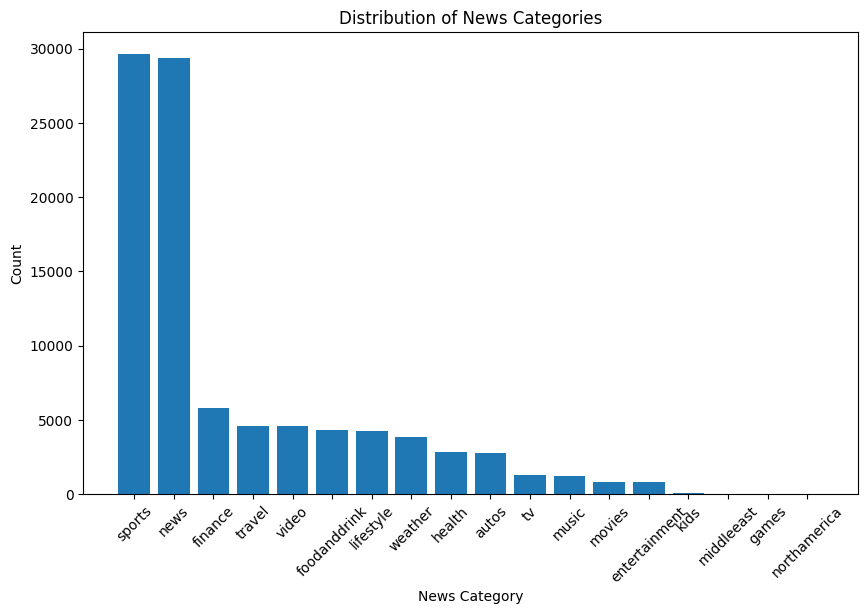

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(category_counts.index, category_counts.values)
plt.xlabel('News Category')
plt.ylabel('Count')
plt.title('Distribution of News Categories')
plt.xticks(rotation=45)
plt.show()


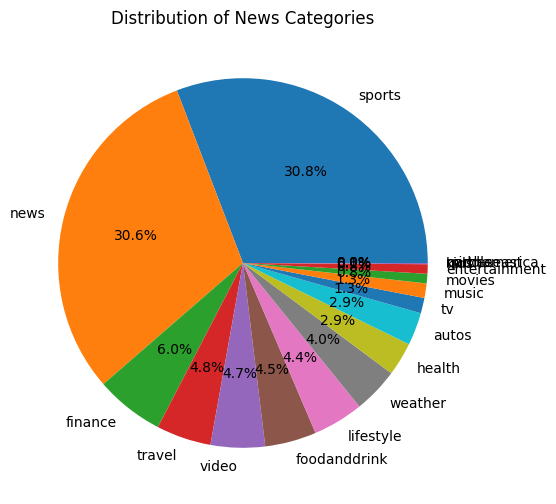

In [ ]:
plt.figure(figsize=(10, 6))
plt.pie(category_counts.values, labels=category_counts.index, autopct='%1.1f%%')
plt.title('Distribution of News Categories')
plt.show()

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17],
 [Text(0, 0, 'lifestyle'),
  Text(1, 0, 'news'),
  Text(2, 0, 'health'),
  Text(3, 0, 'sports'),
  Text(4, 0, 'weather'),
  Text(5, 0, 'entertainment'),
  Text(6, 0, 'foodanddrink'),
  Text(7, 0, 'autos'),
  Text(8, 0, 'travel'),
  Text(9, 0, 'video'),
  Text(10, 0, 'tv'),
  Text(11, 0, 'finance'),
  Text(12, 0, 'movies'),
  Text(13, 0, 'music'),
  Text(14, 0, 'kids'),
  Text(15, 0, 'middleeast'),
  Text(16, 0, 'games'),
  Text(17, 0, 'northamerica')])

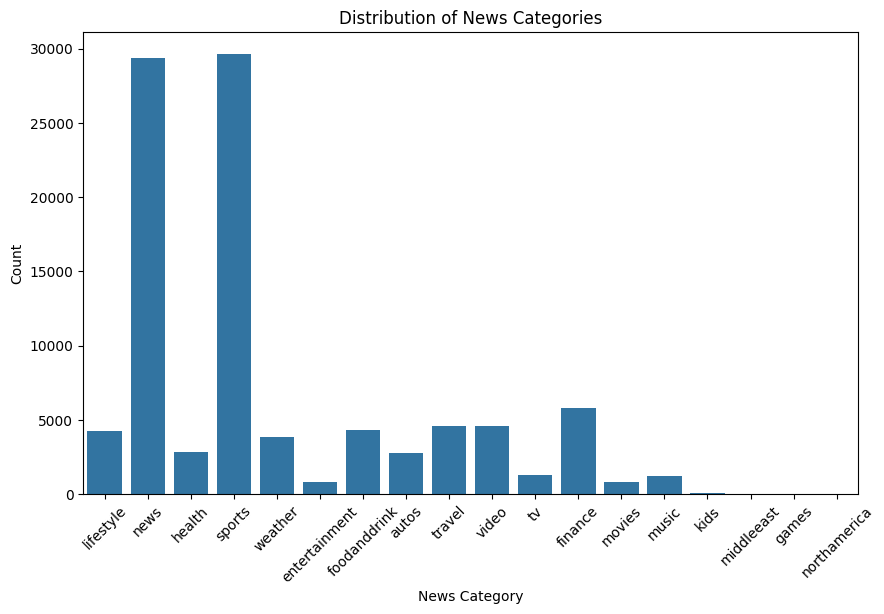

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='News Category')
plt.xlabel('News Category')
plt.ylabel('Count')
plt.title('Distribution of News Categories')
plt.xticks(rotation=45)

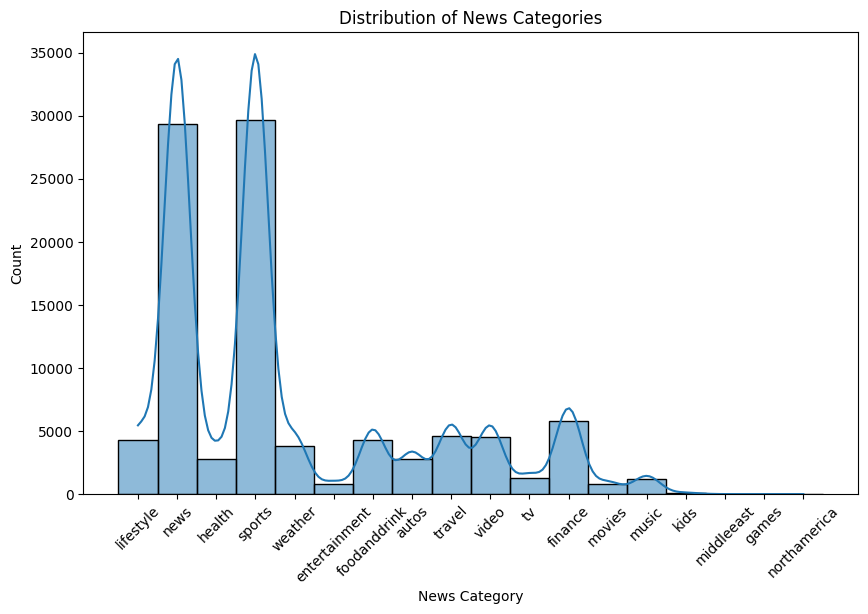

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='News Category', bins=10, kde=True)
plt.xlabel('News Category')
plt.ylabel('Count')
plt.title('Distribution of News Categories')
plt.xticks(rotation=45)
plt.show()

In [ ]:
#Statistical Analysis: Calculate summary statistics like mean, median, standard deviation, and percentiles for numerical columns. This can provide insights into the distribution of the data.
numerical_cols = ['Title', 'News Category']
df[numerical_cols].describe()

,Title,News Category
count,96112,96112
unique,93102,18
top,Powerball Winning Numbers For 10/26/2019 Drawi...,sports
freq,27,29626


In [ ]:
numerical_cols = ['Title', 'Summary']
df[numerical_cols].describe(include='all')

,Title,Summary
count,96112,96112
unique,93102,91653
top,Powerball Winning Numbers For 10/26/2019 Drawi...,What's the weather today? What's the weather f...
freq,27,435


In [ ]:
#2. Feature Engineering
#Text Processing: Extract relevant features from the text content of the news articles. You can use techniques like:
#Tokenization: Split the text into individual words or tokens.
#Stop Word Removal: Remove common words (like "the", "a", "is") that don't carry much meaning.
#Stemming/Lemmatization: Reduce words to their base form to group similar words.
#TF-IDF: Calculate the importance of words in the documen
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_vectorizer = TfidfVectorizer()
text_data = df['Summary']
tfidf_matrix = tfidf_vectorizer.fit_transform(text_data)
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=tfidf_vectorizer.get_feature_names_out())
tfidf_df



,00,000,0003,000dpi,000s,000th,001,0010,003,0040,...,àlvarez,áine,álvarez,árdana,éric,ötztal,ženy,žižek,ダルビッシュ有,死ぬまで毎食唐揚げ食べとけ
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96107,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
96108,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
96109,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
96110,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
category_dummies = pd.get_dummies(df['News Category'], prefix='Category')
category_dummies


,Category_autos,Category_entertainment,Category_finance,Category_foodanddrink,Category_games,Category_health,Category_kids,Category_lifestyle,Category_middleeast,Category_movies,Category_music,Category_news,Category_northamerica,Category_sports,Category_travel,Category_tv,Category_video,Category_weather
0,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False
2,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False
5,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101519,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
101521,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
101522,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False
101523,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [ ]:
# Concatenate the DataFrames
df_encoded = pd.concat([df, category_dummies], axis=1)
df_encoded

,ID,News Category,Title,Summary,Category_autos,Category_entertainment,Category_finance,Category_foodanddrink,Category_games,Category_health,...,Category_middleeast,Category_movies,Category_music,Category_news,Category_northamerica,Category_sports,Category_travel,Category_tv,Category_video,Category_weather
0,N88753,lifestyle,"The Brands Queen Elizabeth, Prince Charles, an...","Shop the notebooks, jackets, and more that the...",False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,N45436,news,Walmart Slashes Prices on Last-Generation iPads,Apple's new iPad releases bring big deals on l...,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
2,N23144,health,50 Worst Habits For Belly Fat,These seemingly harmless habits are holding yo...,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
4,N93187,news,The Cost of Trump's Aid Freeze in the Trenches...,Lt. Ivan Molchanets peeked over a parapet of s...,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False
5,N75236,health,I Was An NBA Wife. Here's How It Affected My M...,"I felt like I was a fraud, and being an NBA wi...",False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
101519,N97700,weather,"Adapting, Learning And Soul Searching: Reflect...",Woolsey Fire Anniversary: A community is forev...,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
101521,N114875,sports,"Devils strike fast, hold off Canucks 2-1","VANCOUVER, British Columbia (AP) Wayne Simmond...",False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
101522,N115249,sports,St. Dominic soccer player tries to kick cancer...,"Sometimes, what happens on the sidelines can b...",False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
101523,N64337,finance,Mansion Monday: Contemporary Des Moines home i...,Among the perks of this unique Des Moines home...,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
#Text Preprocessing: Explore further text preprocessing techniques like stemming or lemmatization to reduce words to their base form and potentially improve model performance.


In [ ]:
import nltk
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Download the 'punkt_tab' data package
nltk.download('punkt_tab')

# Download other necessary data packages
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')

stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    words = word_tokenize(text)
    stemmed_words = [stemmer.stem(word) for word in words]
    lemmatized_words = [lemmatizer.lemmatize(word) for word in stemmed_words]
    return " ".join(lemmatized_words)

df['Processed_Summary'] = df['Summary'].apply(preprocess_text)
print(df[['Summary', 'Processed_Summary']].head())

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


                                             Summary  \
0  Shop the notebooks, jackets, and more that the...   
1  Apple's new iPad releases bring big deals on l...   
2  These seemingly harmless habits are holding yo...   
4  Lt. Ivan Molchanets peeked over a parapet of s...   
5  I felt like I was a fraud, and being an NBA wi...   

                                   Processed_Summary  
0  shop the notebook , jacket , and more that the...  
1  appl 's new ipad releas bring big deal on last...  
2  these seemingli harmless habit are hold you ba...  
4  lt. ivan molchanet peek over a parapet of sand...  
5  i felt like i wa a fraud , and be an nba wife ...  


In [ ]:
#N-grams: Consider using N-grams (sequences of words) as features in addition to individual words to capture more context.


In [ ]:
# prompt: N-grams: Consider using N-grams (sequences of words) as features in addition to individual words to capture more context.

from nltk import ngrams

def generate_ngrams(text, n):
    words = text.split()
    return list(ngrams(words, n))

# Example usage:
text = "This is a sample sentence for n-gram generation."
n = 2  # Generate bigrams (2-grams)
bigrams = generate_ngrams(text, n)
print(bigrams)

# Apply to your dataframe
df['Bigrams'] = df['Processed_Summary'].apply(lambda x: generate_ngrams(x, 2))
print(df[['Processed_Summary', 'Bigrams']].head())

# You can further process these bigrams, for example, by creating a new TF-IDF matrix
# that incorporates bigrams along with individual words.


[('This', 'is'), ('is', 'a'), ('a', 'sample'), ('sample', 'sentence'), ('sentence', 'for'), ('for', 'n-gram'), ('n-gram', 'generation.')]
                                   Processed_Summary  \
0  shop the notebook , jacket , and more that the...   
1  appl 's new ipad releas bring big deal on last...   
2  these seemingli harmless habit are hold you ba...   
4  lt. ivan molchanet peek over a parapet of sand...   
5  i felt like i wa a fraud , and be an nba wife ...   

                                             Bigrams  
0  [(shop, the), (the, notebook), (notebook, ,), ...  
1  [(appl, 's), ('s, new), (new, ipad), (ipad, re...  
2  [(these, seemingli), (seemingli, harmless), (h...  
4  [(lt., ivan), (ivan, molchanet), (molchanet, p...  
5  [(i, felt), (felt, like), (like, i), (i, wa), ...  


In [ ]:
#Sentiment Analysis: Analyze the sentiment ex
#pressed in the news articles to create a new feature representing the overall tone or emotion.


In [ ]:
# prompt: Sentiment Analysis: Analyze the sentiment expressed in the news articles to create a new feature representing the overall tone or emotion.

# Install necessary libraries
!pip install textblob

# Import necessary libraries
from textblob import TextBlob

# Function to get sentiment polarity
def get_sentiment(text):
    analysis = TextBlob(text)
    return analysis.sentiment.polarity

# Apply sentiment analysis to the 'Summary' column
df['Sentiment'] = df['Summary'].apply(get_sentiment)

# Display the DataFrame with the new 'Sentiment' column
print(df[['Summary', 'Sentiment']].head())


                                             Summary  Sentiment
0  Shop the notebooks, jackets, and more that the...   0.318182
1  Apple's new iPad releases bring big deals on l...   0.045455
2  These seemingly harmless habits are holding yo...   0.350000
4  Lt. Ivan Molchanets peeked over a parapet of s...  -0.033333
5  I felt like I was a fraud, and being an NBA wi...   0.100000


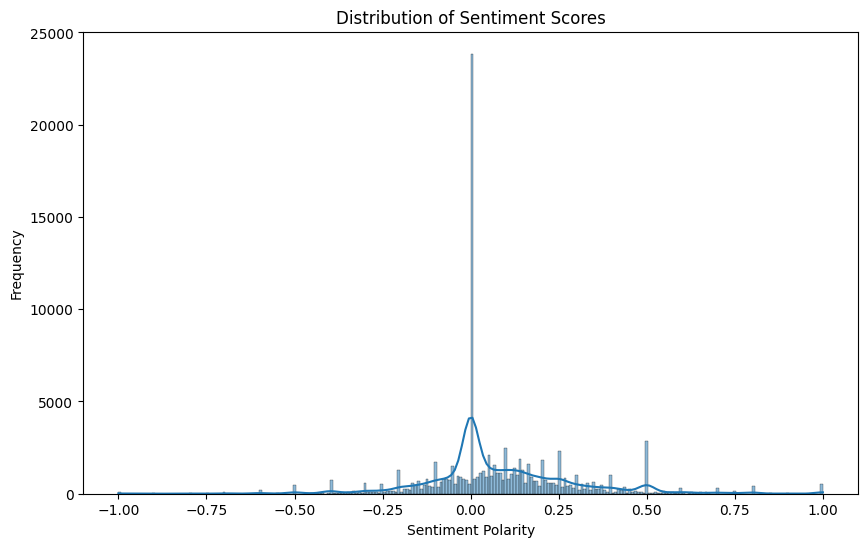

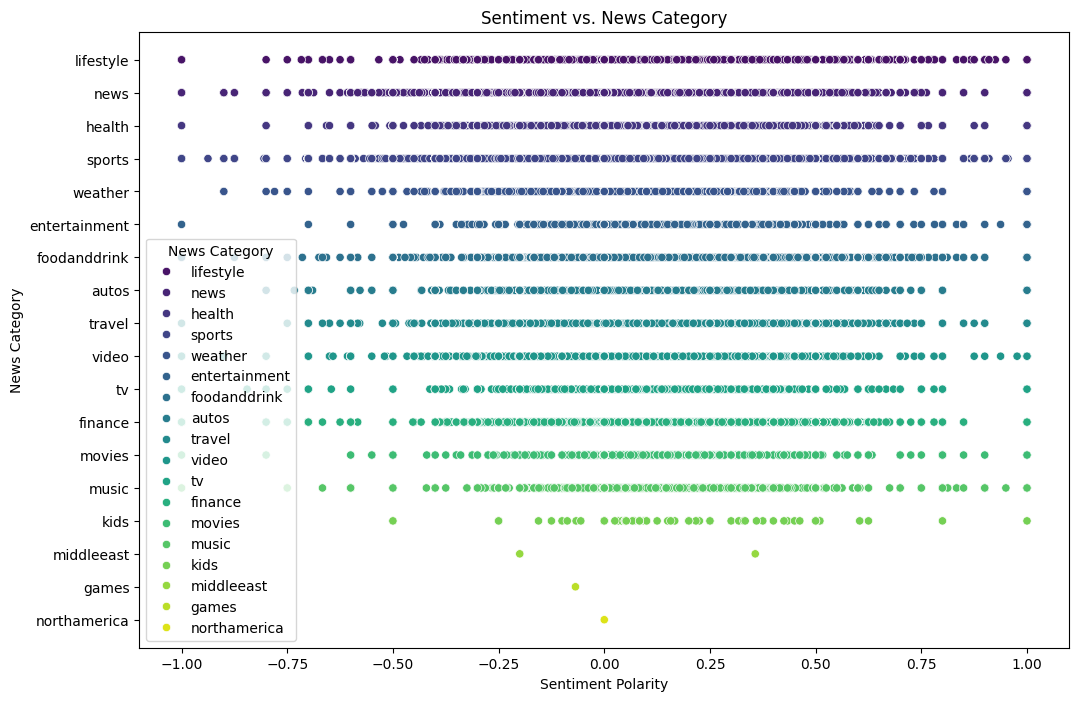

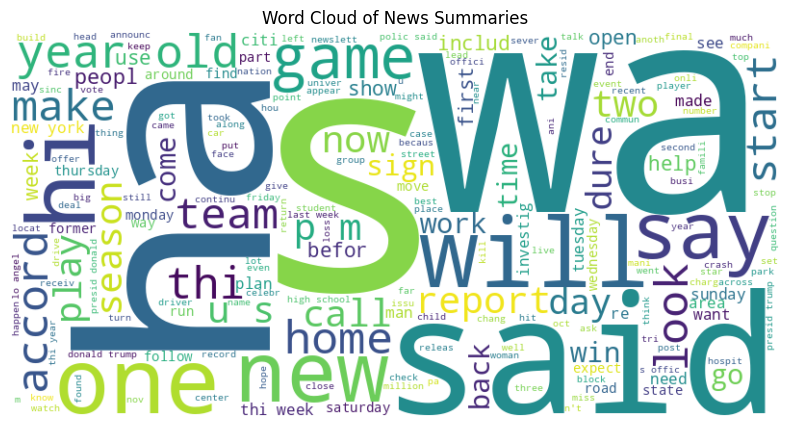

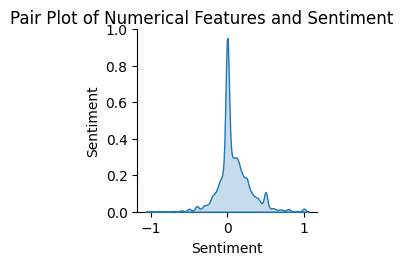

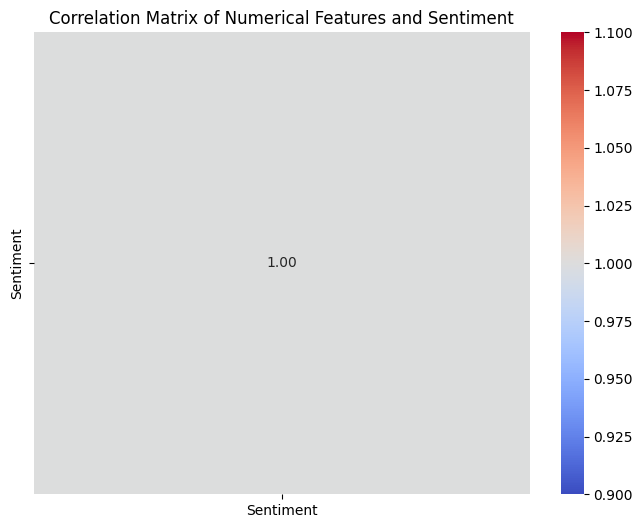

In [ ]:
# prompt: Visualization: While your existing visualizations are informative, consider adding more to further explore the data:

import matplotlib.pyplot as plt
# Visualize the distribution of sentiment scores
plt.figure(figsize=(10, 6))
sns.histplot(df['Sentiment'], kde=True)
plt.title('Distribution of Sentiment Scores')
plt.xlabel('Sentiment Polarity')
plt.ylabel('Frequency')
plt.show()

# Create a scatter plot of sentiment vs. news category
plt.figure(figsize=(12, 8))
sns.scatterplot(x='Sentiment', y='News Category', data=df, hue='News Category', palette='viridis')
plt.title('Sentiment vs. News Category')
plt.xlabel('Sentiment Polarity')
plt.ylabel('News Category')
plt.show()


# Word Cloud: Create a word cloud visualization to highlight frequently occurring words in the news summaries.
from wordcloud import WordCloud

text = " ".join(df['Processed_Summary'].astype(str))  # Combine all processed summaries
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title('Word Cloud of News Summaries')
plt.show()


# Explore relationships between numerical features and sentiment using pair plots or correlation matrices.


# Pair plot for numerical features and sentiment:
numerical_features = ['Sentiment']  # Add other numerical features if available
sns.pairplot(df[numerical_features], diag_kind='kde')
plt.suptitle('Pair Plot of Numerical Features and Sentiment', y=1.02)
plt.show()


# Correlation matrix heatmap:
correlation_matrix = df[numerical_features].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features and Sentiment')
plt.show()


In [ ]:
#Statistical Analysis: You've calculated the correlation, but consider exploring other statistical measures:
# Calculate covariance between numerical features and sentiment
covariance_matrix = df[numerical_features].cov()
print("Covariance Matrix:")
print(covariance_matrix)

Covariance Matrix:
           Sentiment
Sentiment   0.048158


In [ ]:
from scipy.stats import ttest_ind
# Perform t-tests or ANOVA to compare sentiment scores across different news categories.
category1 = 'sports'  # Replace with your desired categories
category2 = 'finance'
group1 = df[df['News Category'] == category1]['Sentiment']
group2 = df[df['News Category'] == category2]['Sentiment']

t_statistic, p_value = ttest_ind(group1, group2)
print(f"\nT-test results for sentiment between '{category1}' and '{category2}':")
print(f"T-statistic: {t_statistic}")
print(f"P-value: {p_value}")



T-test results for sentiment between 'sports' and 'finance':
T-statistic: 0.03468169759377321
P-value: 0.9723337508808385


In [ ]:
from scipy.stats import f_oneway
categories = ['sports', 'finance', 'entertainment']  # Example categories
groups = [df[df['News Category'] == cat]['Sentiment'] for cat in categories]
f_statistic, p_value = f_oneway(*groups)
print(f"\nANOVA results for sentiment across multiple categories:")
print(f"F-statistic: {f_statistic}")
print(f"P-value: {p_value}")



ANOVA results for sentiment across multiple categories:
F-statistic: 21.771066551965955
P-value: 3.553271344604006e-10


In [ ]:
# prompt: News Category Prediction: Build a classification model to predict the news category based on the engineered features.

# Assuming 'df' and other necessary variables are defined from the previous code.

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score


# Prepare the data for modeling
X = df['Processed_Summary']  # Use the preprocessed summaries as features
y = df['News Category']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000) # Limit features for better performance

# Fit and transform the training data
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

# Transform the testing data
X_test_tfidf = tfidf_vectorizer.transform(X_test)


# Initialize and train a Logistic Regression model (you can experiment with other models)
model = LogisticRegression(max_iter=1000) # Increase max_iter if needed
model.fit(X_train_tfidf, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test_tfidf)

# Evaluate the model
print(classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))


               precision    recall  f1-score   support

        autos       0.64      0.35      0.45       567
entertainment       0.50      0.09      0.16       148
      finance       0.60      0.47      0.53      1146
 foodanddrink       0.70      0.63      0.66       881
       health       0.67      0.49      0.56       531
         kids       0.00      0.00      0.00        20
    lifestyle       0.50      0.38      0.43       855
       movies       0.64      0.33      0.44       169
        music       0.67      0.43      0.53       212
         news       0.65      0.83      0.73      5972
       sports       0.85      0.94      0.89      5914
       travel       0.53      0.34      0.41       928
           tv       0.48      0.17      0.25       259
        video       0.61      0.30      0.40       906
      weather       0.72      0.62      0.66       715

     accuracy                           0.71     19223
    macro avg       0.58      0.42      0.47     19223
 weighte

In [ ]:
from sklearn.cluster import KMeans

# Assuming 'tfidf_matrix' is from the previous code

# Initialize and fit the model
num_clusters = 5  # Adjust as needed
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
kmeans.fit(tfidf_matrix)

# Get cluster labels
cluster_labels = kmeans.labels_

# Add cluster labels to the DataFrame
df['Cluster'] = cluster_labels
print(df[['Title', 'Cluster']].head())

                                               Title  Cluster
0  The Brands Queen Elizabeth, Prince Charles, an...        0
1    Walmart Slashes Prices on Last-Generation iPads        0
2                      50 Worst Habits For Belly Fat        4
4  The Cost of Trump's Aid Freeze in the Trenches...        0
5  I Was An NBA Wife. Here's How It Affected My M...        2


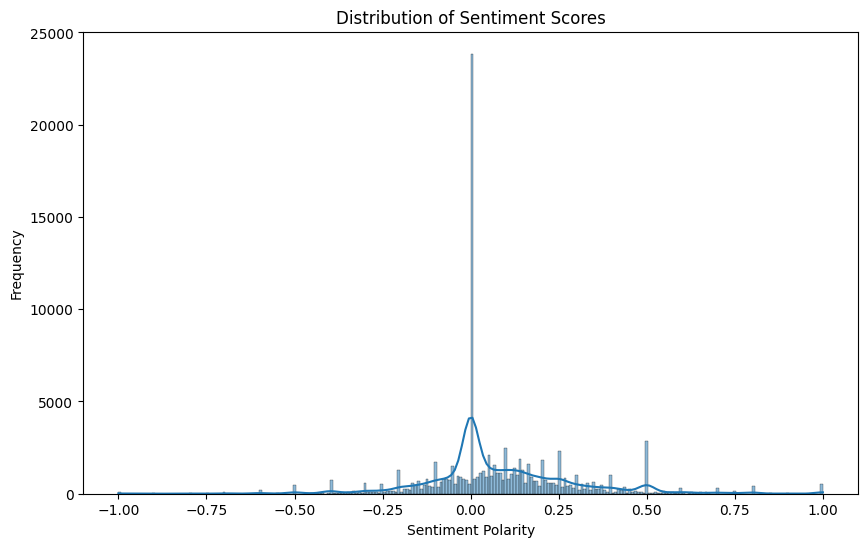

In [ ]:
#clustering plot
# Visualize the distribution of sentiment scores
plt.figure(figsize=(10, 6))
sns.histplot(df['Sentiment'], kde=True)
plt.title('Distribution of Sentiment Scores')
plt.xlabel('Sentiment Polarity')
plt.ylabel('Frequency')
plt.show()

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
# Create a TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer()

# Fit and transform the text data
tfidf_matrix = tfidf_vectorizer.fit_transform(df['Summary'])
tfidf_matrix



<96112x69203 sparse matrix of type '<class 'numpy.float64'>'
	with 2983680 stored elements in Compressed Sparse Row format>

In [ ]:
# prompt: def recommend_news(title, num_recommendations=5):

def recommend_news(title, num_recommendations=5):
    try:
        # Find the index of the input title in the DataFrame
        title_index = df[df['Title'] == title].index[0]

        # Calculate cosine similarity between the input title and all other titles
        cosine_similarities = cosine_similarity(tfidf_matrix[title_index], tfidf_matrix)

        # Get the indices of the most similar titles (excluding the input title itself)
        similar_indices = cosine_similarities.argsort()[0][-num_recommendations-1:-1][::-1]

        # Return the titles of the most similar news articles
        recommendations = df['Title'].iloc[similar_indices].tolist()
        return recommendations
    except IndexError:
        print(f"Title '{title}' not found in the dataset.")
        return []
recommendations=recommend_news("Title ")
print(recommendations)



Title 'Title ' not found in the dataset.
[]


In [ ]:
# Import necessary libraries
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB # Import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

In [ ]:
# Prepare the data (assuming 'df' and 'Processed_Summary' are from previous code)
X = df['Processed_Summary']
y = df['News Category']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC(),
}

# Train and evaluate each model
for model_name, model in models.items():
    print(f"Training and evaluating {model_name}...")
    model.fit(X_train_tfidf, y_train)
# Prepare the data (assuming 'df' and 'Processed_Summary' are from previous code)
X = df['Processed_Summary']
y = df['News Category']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "Linear SVM": LinearSVC(),
}

# Train and evaluate each model
for model_name, model in models.items():
    print(f"Training and evaluating {model_name}...")
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    print(classification_report(y_test, y_pred))
    print(f"{model_name} Accuracy: {accuracy_score(y_test, y_pred)}")

Training and evaluating Logistic Regression...
Training and evaluating Naive Bayes...
Training and evaluating Linear SVM...
Training and evaluating Logistic Regression...
               precision    recall  f1-score   support

        autos       0.64      0.35      0.45       567
entertainment       0.50      0.09      0.16       148
      finance       0.60      0.47      0.53      1146
 foodanddrink       0.70      0.63      0.66       881
       health       0.67      0.49      0.56       531
         kids       0.00      0.00      0.00        20
    lifestyle       0.50      0.38      0.43       855
       movies       0.64      0.33      0.44       169
        music       0.67      0.43      0.53       212
         news       0.65      0.83      0.73      5972
       sports       0.85      0.94      0.89      5914
       travel       0.53      0.34      0.41       928
           tv       0.48      0.17      0.25       259
        video       0.61      0.30      0.40       906
   

In [ ]:
#plot of navie byes

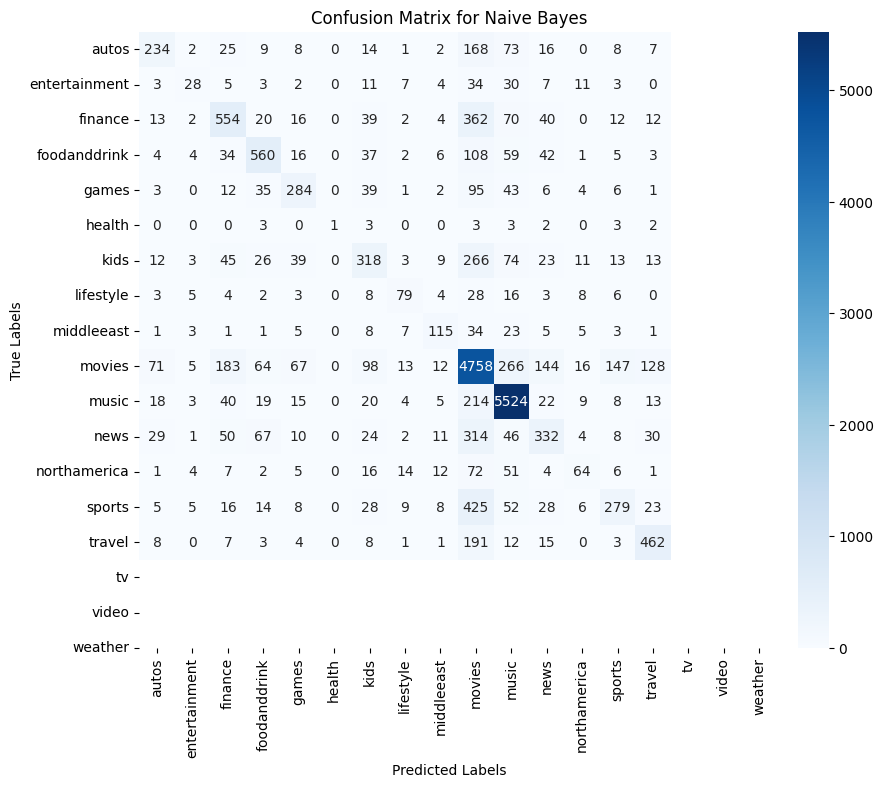

In [ ]:
# prompt: #plot of navie byes

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Assuming 'y_test' and 'y_pred' are from the Naive Bayes model evaluation
# Get the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix for Naive Bayes")
plt.show()
